In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from public_tests_a1 import * 

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)

In [6]:
# Splitting data set
#DATA GENRATING
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print(X.shape,y.shape)

(18,) (18,)


In [7]:
#SPLITTING DATA USING SKLEARN ROUTINE
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(12,) (12,)
(6,) (6,)


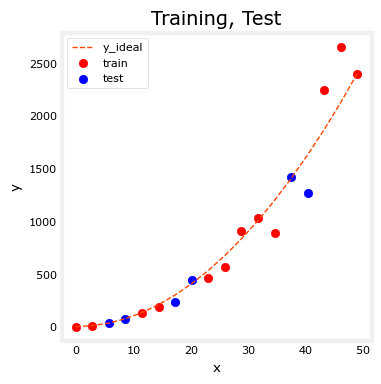

In [8]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_test, y_test,   color = "blue",   label="test")
ax.legend(loc='upper left')
plt.show()

In [9]:
#Error calculation for model evaluation, linear regression

def eval_mse(y , yhat):
    m = len(y)
    err = 0.0
    for i in range(m):
        err += (y[i] - yhat[i]) ** 2
    err = err/(2* m)
    return(err)

In [10]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 All tests passed.


In [14]:
# create a model in sklearn, train on training data
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train,y_train)


# predict on training data, find training error
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)


# predict on test data, find error
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

In [15]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 2086.18, test err 21384.05


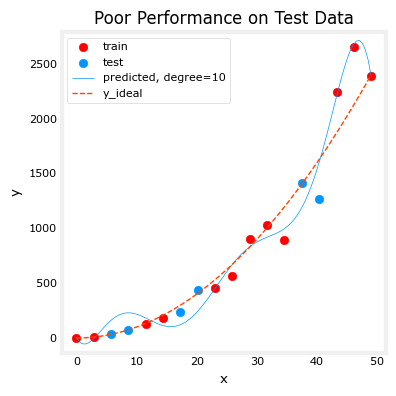

In [16]:
# plot predictions over data range 
x = np.linspace(0,int(X.max()),100)  # predict values for plot
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

This model would be described as 1) is overfitting, 2) has high variance 3) 'generalizes' poorly.

In [17]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine 
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


In [18]:
#Bias and Variance

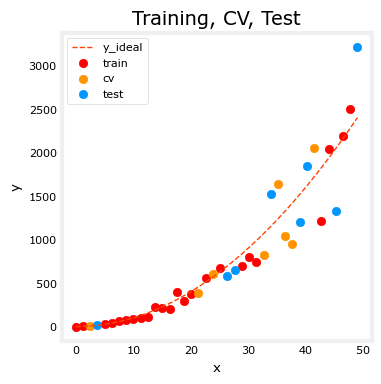

In [19]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, CV, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

In [23]:
#Finding the optimal degree
max_degree = 9
err_train = np.zeros(max_degree)
err_cv = np.zeros(max_degree)
x = np.linspace(0,int(X.max()),100)
y_pred = np.zeros((100,max_degree))

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

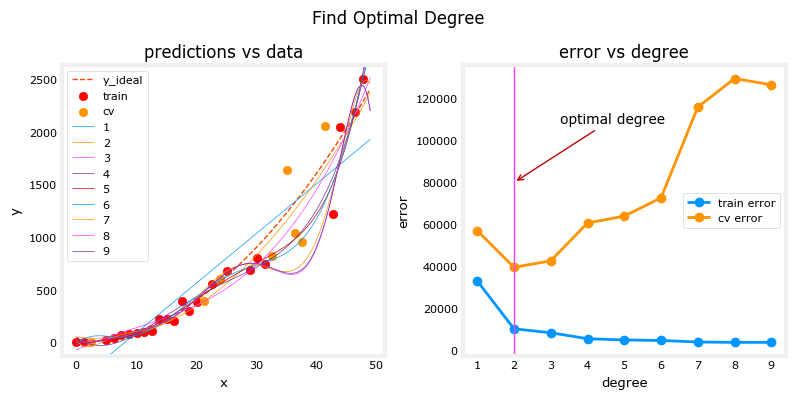

In [24]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

In [26]:
#Tuning Regularization.
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv)

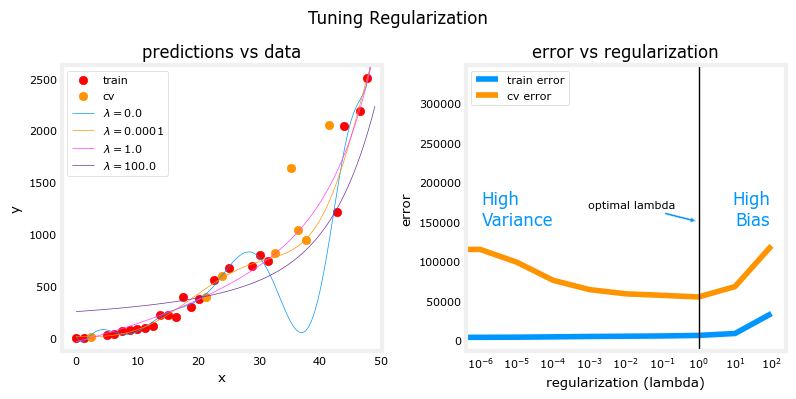

In [27]:
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

In [28]:
#Increasing Training Set Size (m)


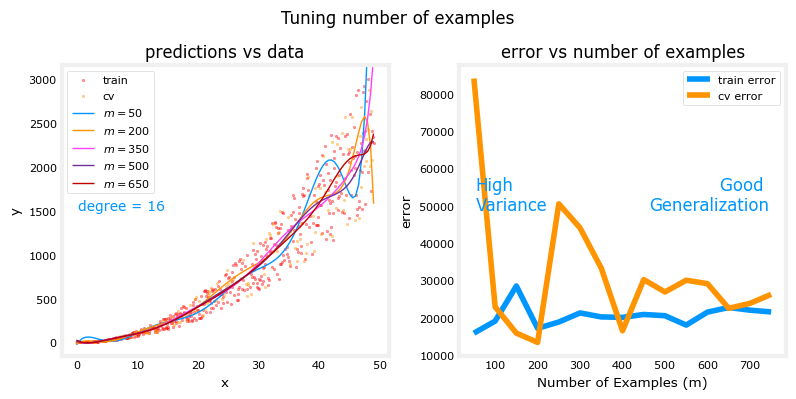

In [29]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

In [30]:
#Neural Networks

In [31]:
X, y, centers, classes, std = gen_blobs()
# split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


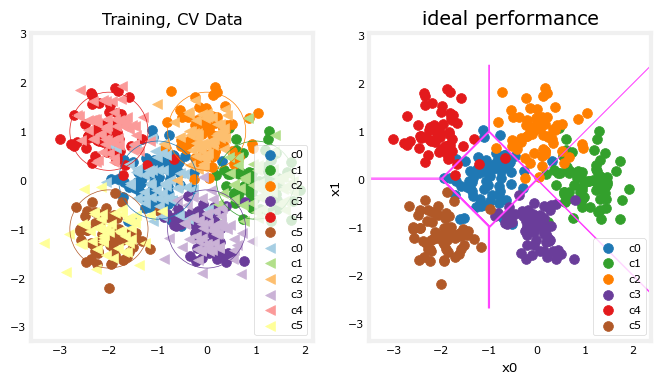

In [32]:
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

In [33]:
#classification error
def eval_cat_err(y, yhat):
    m = len(y)
    incorrect = 0
    for i in range(m):
         if yhat[i] != y[i]:
            incorrect += 1
    cerr = incorrect/m
    return(cerr)
            

In [34]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 All tests passed.


In [35]:
#Model Complexity

In [36]:
tf.random.set_seed(1234)
model = Sequential(
    [
        Dense(units=120, activation='relu'),
        Dense(units=40, activation='relu'),
        Dense(units=6, activation='linear')
    ],name = 'complex'
)

model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)


In [37]:
# BEGIN UNIT TEST
model.fit(
    X_train, y_train,
    epochs=1000
)
# END UNIT TEST

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 1.1224
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 0.4277
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.3534
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - loss: 0.2705
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 0.2491
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.2431
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.2327
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.2239
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.2190
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - loss: 0.2175
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - loss: 0.2177
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - loss: 0.2130
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 0.2112
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - loss: 0.2109
Epoch 15/1000
13/13 ━━━━━━━━━

In [39]:
model.summary()

Model: "complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 160us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step


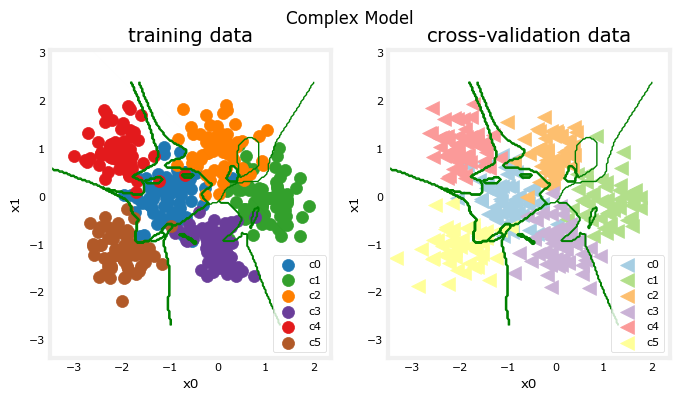

In [42]:
#PREDICTION
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

In [44]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")
                        
                                     

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step
categorization error, training, complex model: 0.003
categorization error, cv,       complex model: 0.119


This large gap between a near-perfect training error and a noticeably higher cross-validation error is the textbook signature of High Variance (Overfitting).

In [45]:
#Simple model
tf.random.set_seed(1234)
model_s = Sequential(
    [
        Dense(units = 6, activation='relu'),
        Dense(units = 6, activation='linear')
    ],name = 'simple'
)
model_s.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01)
)

In [46]:
model_s.fit(X_train,y_train,epochs=1000)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 1.8696
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - loss: 1.5846
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 1.3799
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 1.1943
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 1.0230
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - loss: 0.8727
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.7492
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.6519
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.5772
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.5201
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.4765
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - loss: 0.4430
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - loss: 0.4167
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.3955
Epoch 15/1000
13/13 ━━━━━━━━━

In [48]:
model_s.summary()

Model: "simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182 (1.42 KB)

 Trainable params: 60 (480.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (976.00 B)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 146us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step


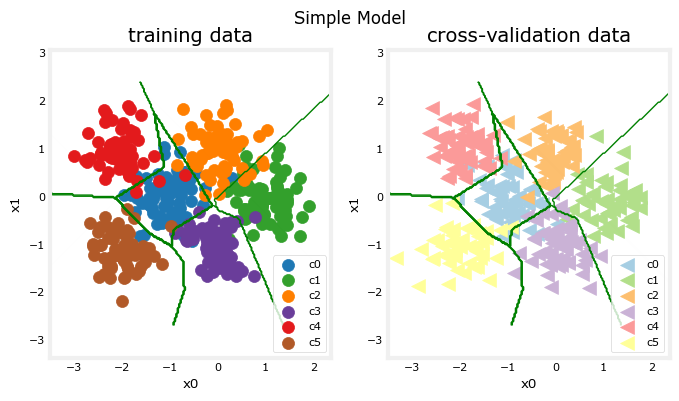

In [49]:
#PREDICTION
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis = 1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

In [50]:
#CLASSIFICATION ERROR
training_cerr_simple = eval_cat_err(y_train,model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv,model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step
categorization error, training, simple model, 0.070, complex model: 0.003
categorization error, cv,       simple model, 0.072, complex model: 0.119


In [51]:
#Regularization

In [53]:
tf.random.set_seed(1234)
model_r = Sequential(
    [
        Dense(units = 120, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(units = 40, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(units = 6, activation='linear')
    ], name = "ComplexRegularized"
)
model_r.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer= tf.keras.optimizers.Adam(0.01),
)

In [54]:
#TESTS
model_r.fit(X_train,y_train,epochs=1000)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 4.4486
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 1.6841
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 1.3477
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 1.0991
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - loss: 0.9983
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.9438
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - loss: 0.9030
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 0.8658
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.8390
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 0.8114
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 0.7894
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 0.7705
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 0.7535
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - loss: 0.7355
Epoch 15/1000
13/13 ━━━━━━━━━

In [55]:
model_r.summary()

Model: "ComplexRegularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step


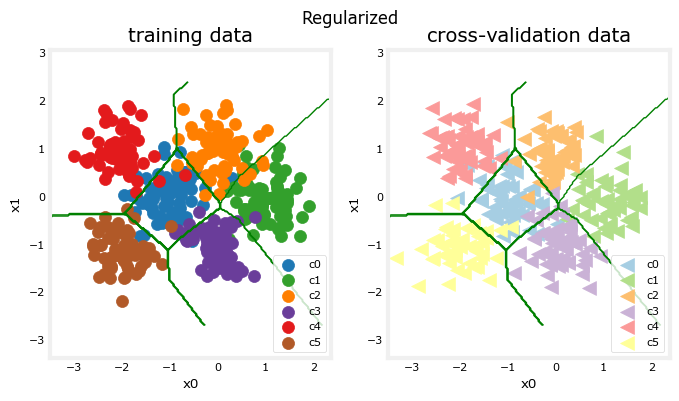

In [58]:
#PREDICTION
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

In [59]:
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
categorization error, training, regularized: 0.085, simple model, 0.070, complex model: 0.003
categorization error, cv,       regularized: 0.081, simple model, 0.072, complex model: 0.119
